In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("AmesHousing.csv")
df.sample(2)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
733,734,903226130,50,RM,50.0,6000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,128000
130,131,534451150,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500


In [4]:
df.shape

(2930, 82)

In [5]:
# Drop Order and PID
df = df.drop(columns=['Order', 'PID'])
df.sample(2)

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
65,50,RL,56.0,14720,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,410000
277,50,RL,89.0,11792,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Abnorml,64000


In [6]:
missing_values_columns = df.isna().sum()
print(missing_values_columns[missing_values_columns > 0])

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [7]:
df['Alley'] = df['Alley'].fillna('None')
df['Alley'].sample(4)

df['Fireplace Qu'] = df['Fireplace Qu'].fillna("None")
df['Fireplace Qu'].sample(4)

df['Fence'] = df['Fence'].fillna('None')
df['Fence'].sample(4)

df['Pool QC'] = df['Pool QC'].fillna("None")
df['Pool QC'].sample(4)

df['Misc Feature'] = df['Misc Feature'].fillna("None")
df['Misc Feature'].sample(4)

df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna("None")
df['Mas Vnr Type'].sample(4)

# BsmtFin Type 2, BsmtFin Type 1, Bsmt Exposure, Bsmt Cond, Bsmt Qual
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna("None")
df['BsmtFin Type 2'].sample(4)

df['BsmtFin Type 1'] = df['BsmtFin Type 1'].fillna("None")
df['BsmtFin Type 1'].sample(4)

df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna("None")
df['Bsmt Exposure'].sample(4)

df['Bsmt Cond'] = df['Bsmt Cond'].fillna("None")
df['Bsmt Cond'].sample(4)

df['Bsmt Qual'] = df['Bsmt Qual'].fillna("None")
df['Bsmt Qual'].sample(4)

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Fill the missing value of Total Basement SF with 0 moreover, 
# if the total Basement square feet is 0 then the Basement other features since they are dependent will also be set to none.
df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(0)
df.loc[
    (df['Total Bsmt SF'] == 0),
    ['BsmtFin Type 2', 'BsmtFin Type 1', 'Bsmt Exposure', 'Bsmt Cond', 'Bsmt Qual']
] = "None"
# BsmtFin SF 1, BsmtFin SF 2, Bsmt Unf SF
df.loc[
    (df['Total Bsmt SF'] == 0),
    ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
] = 0
df['Bsmt Full Bath'] = df['Bsmt Full Bath'].fillna(0)
df['Bsmt Half Bath'] = df['Bsmt Half Bath'].fillna(0)

# If Mansory Venue type is none then the area is subsequently zero.
df.loc[
    (df['Mas Vnr Type'] == 'None') &
    (df['Mas Vnr Area'] != 0),
    'Mas Vnr Area'
] = 0

# If Garage area is 0 then the equivalent column ordinal/nominal shall also be None/0.
df['Garage Area'] = df['Garage Area'].fillna(0)
df.loc[
    (df['Garage Area'] == 0),
    ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
] = "None"
df['Garage Finish'] = df['Garage Finish'].fillna("None")
df['Garage Qual'] = df['Garage Qual'].fillna("None")
df['Garage Cond'] = df['Garage Cond'].fillna("None")
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)
df.loc[
    (df['Garage Area'] == 0),
    'Garage Cars'
] = 0

df['Lot Frontage'] = (
    df['Lot Frontage'].fillna(df.groupby('Neighborhood')['Lot Frontage'].transform('median'))
)

df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].mode()[0])

- Fill NaN with None
- For Mas Vnr Type Set the equivalent column value Mas Vnr Type to Zero as well.
- For Bsmt if Total Bsmt SF is 0 then the equivalent Basement Columns shall be set to None (Ordinal) or Zero (Nominal)
- Electrical feature only has one missing value set that to mode of any.
- Garage Type replace with None moreover, The equivalent features that do not have any values shall be dropped or filled with Mode.

In [8]:
missing_values_columns = df.isna().sum()
print(missing_values_columns[missing_values_columns > 0])

Series([], dtype: int64)


#### Exploratory Data Analysis (EDA) 
Exploratory Data Analysis
- Distribution of features
- Distribution of target
- Correlations
- Outliers

**The purpose of EDA:**
Its purpose is to answer four questions:
- What does each feature look like?
- How does each feature relate to the target (SalePrice)?
- How do features relate to one another?
- Are there anomalies (outliers, skewness, leakage, etc.) that require preprocessing?

In [12]:
# Numerical Features EDA
numerical_columns = df.select_dtypes(include=np.number)
numerical_columns

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,...,210,62,0,0,0,0,0,5,2010,215000
1,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,140,0,0,0,120,0,0,6,2010,105000
2,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,393,36,0,0,0,0,12500,6,2010,172000
3,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,...,0,0,0,0,0,0,0,4,2010,244000
4,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,212,34,0,0,0,0,0,3,2010,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,37.0,7937,6,6,1984,1984,0.0,819.0,0.0,...,120,0,0,0,0,0,0,3,2006,142500
2926,20,74.0,8885,5,5,1983,1983,0.0,301.0,324.0,...,164,0,0,0,0,0,0,6,2006,131000
2927,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,80,32,0,0,0,0,700,7,2006,132000
2928,20,77.0,10010,5,5,1974,1975,0.0,1071.0,123.0,...,240,38,0,0,0,0,0,4,2006,170000


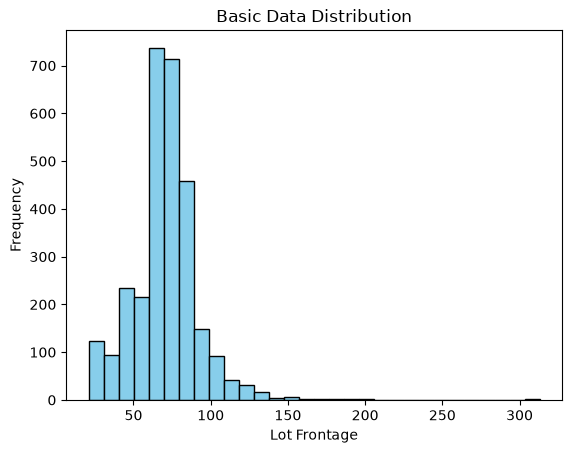

In [14]:
plt.hist(numerical_columns['Lot Frontage'], bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Lot Frontage')
plt.ylabel('Frequency')
plt.title('Basic Data Distribution')

# Display the plot
plt.show()